$$\Huge\mbox{PUC Minas}$$

$$\large\mbox{Séries Temporais}$$

$$\small\mbox{Prof. Anaíle Rabelo}$$

## Aula Prática: Modelos ARIMA e AutoARIMA

Dando continuidade aos nossos estudos de modelagem estatística, hoje evoluiremos do modelo ARMA para o **ARIMA (AutoRegressivo Integrado de Média Móvel)**. 

A principal diferença é a letra **I (Integrado)**, que introduz o conceito de **diferenciação ($d$)**. Isso nos permite lidar com séries que **não são estacionárias** (que possuem tendência), diferenciando os dados até que a média se estabilize.

Nesta aula, faremos:
1. **Análise de Estacionariedade:** Uso do teste ADF para descobrir a ordem de integração ($d$).
2. **Definição de Baseline:** Criação de um modelo Naive (Ingênuo) para servir de benchmark.
3. **ARIMA Tradicional:** Busca em grade (Grid Search) manual para encontrar os melhores parâmetros ($p, d, q$) via `statsmodels`.
4. **AutoARIMA:** Uso da biblioteca ultrarrápida `statsforecast` para seleção automatizada e otimizada de hiperparâmetros.
5. **Avaliação Comparativa:** Comparação dos três cenários usando MAE, MSE, RMSE, MAPE, sMAPE e MASE.

### 1. Preliminares: Importação e Estilo

Importaremos as bibliotecas clássicas de visualização e modelagem, além do moderno `StatsForecast`.

In [ ]:
#!pip install statsforecast

In [1]:
# Bibliotecas Base
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas Tradicionais de Séries Temporais (Statsmodels)
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Bibliotecas Modernas de Previsão em Larga Escala (Nixtla)
# Caso não tenha instalado, execute no terminal: pip install statsforecast
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

In [2]:
# Configuração do padrão visual (estilo dashboard)
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#FFFFFF',    
    'axes.facecolor': '#FFFFFF',      
    'savefig.facecolor':'#000000',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
    'grid.color': '#888888',
    'grid.linewidth': '0.1',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18, 7)

### 2. Carregamento dos Dados

Vamos trabalhar com a famosa série de passageiros aéreos.

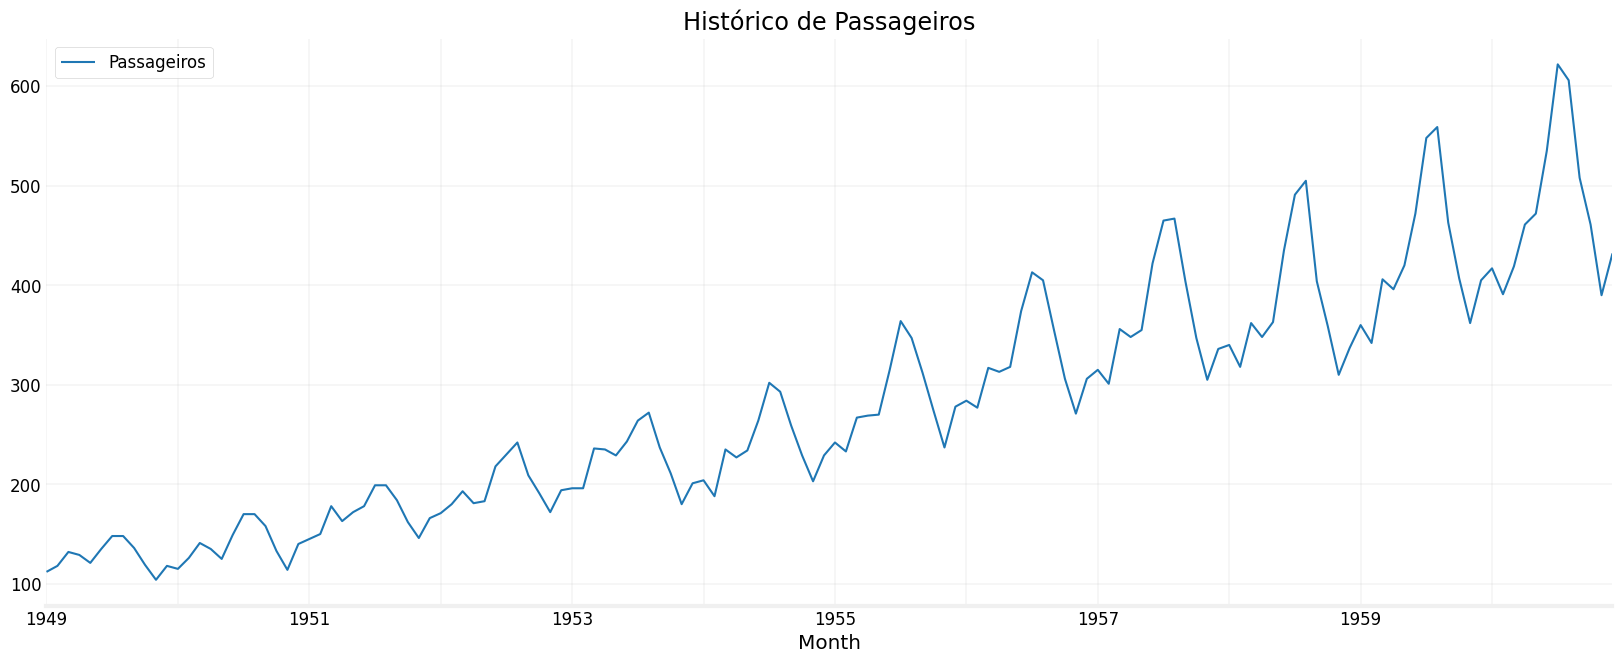

In [13]:
# Carregamento dos dados (com fallback embutido para garantir a execução)
try:
    MinhaSerieTemporal = pd.read_csv('Passageiros.csv', index_col=0)
except FileNotFoundError:
    import statsmodels.api as sm
    data = sm.datasets.get_rdataset("AirPassengers").data
    data['time'] = pd.date_range(start='1949-01-01', periods=len(data), freq='MS')
    data.set_index('time', inplace=True)
    MinhaSerieTemporal = pd.DataFrame(data['value'])

MinhaSerieTemporal.index = pd.to_datetime(MinhaSerieTemporal.index)
MinhaSerieTemporal.columns = ['Passageiros']

MinhaSerieTemporal.plot(title="Histórico de Passageiros", color="#1f77b4");

### 3. Separação: Treino e Teste

A separação temporal é regra de ouro. Usaremos os últimos 10% da série para testar o poder de generalização (previsão futura) dos nossos modelos.

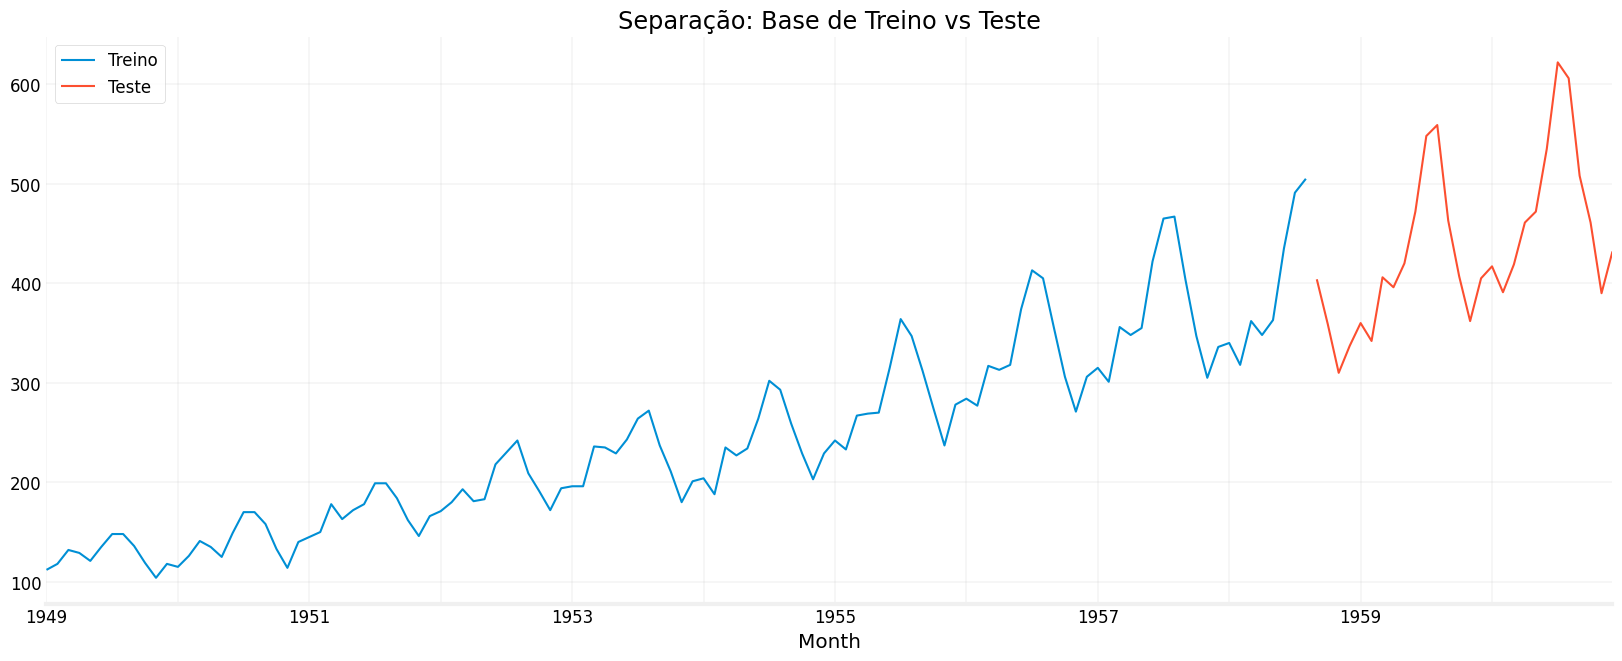

In [14]:
PercentualTeste = 20
PeriodoTeste = int(PercentualTeste * len(MinhaSerieTemporal) / 100)

TreinoDF = MinhaSerieTemporal.iloc[:-PeriodoTeste].copy()
TesteDF = MinhaSerieTemporal.iloc[-PeriodoTeste:].copy()

TreinoDF.rename(columns={'Passageiros': 'Treino'}, inplace=True)
TesteDF.rename(columns={'Passageiros': 'Teste'}, inplace=True)

pd.concat([TreinoDF, TesteDF], axis=1).plot(title='Separação: Base de Treino vs Teste');

### 4. Análise de Estacionariedade e Diferenciação

O modelo ARIMA exige que a série de entrada seja estacionária. Como nossa série tem uma clara tendência de alta, precisamos aplicar **diferenças finitas**.

In [15]:
print("--- Teste ADF na Série Original ---")
adf_orig = adfuller(TreinoDF['Treino'])
print(f'Estatística ADF: {adf_orig[0]:2.4f} | p-value: {adf_orig[1]*100:2.4f} %')
print("A série não é estacionária (p-value > 5%).\n")

# Aplicando a 1ª diferença (d=1)
diff_1 = np.diff(TreinoDF['Treino'], n=1)
print("--- Teste ADF na 1ª Diferença ---")
adf_diff1 = adfuller(diff_1)
print(f'Estatística ADF: {adf_diff1[0]:2.4f} | p-value: {adf_diff1[1]*100:2.4f} %')

# Aplicando a 2ª diferença (d=2) apenas para investigação exploratória
diff_2 = np.diff(TreinoDF['Treino'], n=2)
print("\n--- Teste ADF na 2ª Diferença ---")
adf_diff2 = adfuller(diff_2)
print(f'Estatística ADF: {adf_diff2[0]:2.4f} | p-value: {adf_diff2[1]*100:2.4f} %')
print("Observe que d=1 ou d=2 estabilizam a média da série.")

--- Teste ADF na Série Original ---
Estatística ADF: -0.0766 | p-value: 95.1717 %
A série não é estacionária (p-value > 5%).

--- Teste ADF na 1ª Diferença ---
Estatística ADF: -2.7088 | p-value: 7.2530 %

--- Teste ADF na 2ª Diferença ---
Estatística ADF: -6.9250 | p-value: 0.0000 %
Observe que d=1 ou d=2 estabilizam a média da série.


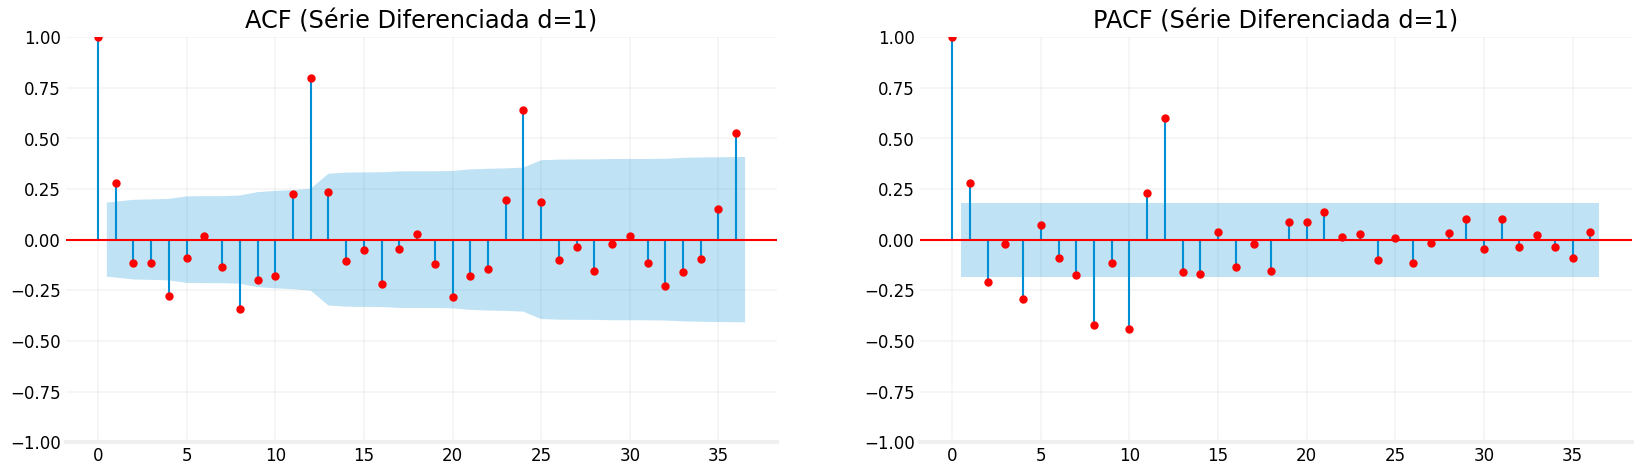

In [16]:
# Analisando a 1ª diferença (d=1) para tentar extrair os componentes p (PACF) e q (ACF)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(diff_1, lags=36, title="ACF (Série Diferenciada d=1)", color="red", ax=axes[0])
plot_pacf(diff_1, lags=36, title="PACF (Série Diferenciada d=1)", color="red", ax=axes[1])
plt.show()

### 5. Função Robusta de Validação de Erros

Para provarmos cientificamente a qualidade do nosso modelo, calcularemos as métricas solicitadas: **MAE, MSE, RMSE, MAPE, sMAPE e MASE**.

In [17]:
def calcular_metricas(y_true, y_pred, y_train):
    y_true, y_pred, y_train = np.array(y_true), np.array(y_pred), np.array(y_train)
    
    erros = y_true - y_pred
    
    mae = np.mean(np.abs(erros))
    mse = np.mean(erros**2)
    rmse = np.sqrt(mse)
    
    # Evitar divisão por zero
    mape = np.mean(np.abs(erros / np.where(y_true == 0, 1e-10, y_true))) * 100
    smape = np.mean(2.0 * np.abs(erros) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100
    
    # MASE: compara com um baseline ingênuo in-sample
    mae_naive_train = np.mean(np.abs(np.diff(y_train)))
    mase = mae / mae_naive_train if mae_naive_train != 0 else np.nan
    
    return pd.Series({
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'MASE': mase
    })

### 6. Modelo de Benchmark (Baseline Naive)

O modelo Naive Sazonal (projetar o valor do último ano para o próximo) ou o Naive Simples (projetar o último mês) são excelentes balizadores.

In [18]:
# Aqui usaremos o Naive Simples: projeta o último ponto do treino para o futuro
ultimo_ponto_treino = TreinoDF['Treino'].iloc[-1]
PrevisaoNaive = np.repeat(ultimo_ponto_treino, len(TesteDF))

metricas_naive = calcular_metricas(TesteDF['Teste'], PrevisaoNaive, TreinoDF['Treino'])
print("Métricas Baseline Naive:")
print(metricas_naive.round(2))

Métricas Baseline Naive:
MAE             91.86
MSE          10656.71
RMSE           103.23
MAPE (%)        23.05
sMAPE (%)       20.18
MASE             4.37
dtype: float64


### 7. ARIMA Tradicional: Grid Search via Statsmodels

Vamos realizar um loop testando permutações de $p, d, q$ para encontrar o modelo de menor Critério de Informação de Akaike (AIC).

In [19]:
print("Executando Grid Search Manual (Isto pode levar alguns segundos)...")
pRange = 3
dRange = 2
qRange = 3

ResultadosAIC = []

for d in range(dRange):
    for p in range(pRange):
        for q in range(qRange):
            try:
                # Para não sujar o terminal, suprimimos os warnings de convergência
                modelo_loop = SARIMAX(TreinoDF['Treino'], order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
                resultado_loop = modelo_loop.fit(disp=False)
                ResultadosAIC.append({'Modelo': f'ARIMA({p},{d},{q})', 'AIC': resultado_loop.aic})
            except:
                continue

GridDF = pd.DataFrame(ResultadosAIC).sort_values(by='AIC').reset_index(drop=True)
print("Top 5 modelos ARIMA encontrados:")
display(GridDF.head())

Executando Grid Search Manual (Isto pode levar alguns segundos)...


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py

Top 5 modelos ARIMA encontrados:


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py

,Modelo,AIC
0,"ARIMA(2,0,2)",1037.426957
1,"ARIMA(1,1,2)",1041.340586
2,"ARIMA(2,1,2)",1041.609784
3,"ARIMA(0,1,2)",1043.905761
4,"ARIMA(1,1,1)",1049.940875


In [20]:
# Ajuste do modelo escolhido na aula anterior (ex: ARIMA(3,1,3) ou ARIMA(1,1,0))
# Vamos pegar os parâmetros do melhor modelo no topo do grid
melhor_p, melhor_d, melhor_q = 2, 0, 2 

print(f"Ajustando o modelo final ARIMA({melhor_p},{melhor_d},{melhor_q})...")
modelo_arima = SARIMAX(TreinoDF['Treino'], order=(melhor_p, melhor_d, melhor_q))
resultado_arima = modelo_arima.fit(disp=False)

# Previsão para a base de teste
inicio = len(TreinoDF)
fim = len(TreinoDF) + len(TesteDF) - 1
PrevisaoARIMA_Manual = resultado_arima.predict(start=inicio, end=fim, dynamic=False)

Ajustando o modelo final ARIMA(2,0,2)...


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 8. A Abordagem Moderna: AutoARIMA com StatsForecast

Enquanto a busca manual via laços `for` é altamente didática, no dia a dia do Cientista de Dados em produção, usamos bibliotecas ultraotimizadas. O `StatsForecast` da Nixtla é capaz de rodar modelos AutoARIMA em frações de segundo, varrendo não só a parte não-sazonal ($p, d, q$) mas também a componente sazonal ($P, D, Q, m$).

In [21]:
# O StatsForecast exige o formato longo: ['unique_id', 'ds', 'y']
SerieSF = pd.DataFrame({
    'unique_id': 'Passageiros',
    'ds': TreinoDF.index,
    'y': TreinoDF['Treino'].values
})

display(SerieSF.head())

,unique_id,ds,y
0,Passageiros,1949-01-01,112
1,Passageiros,1949-02-01,118
2,Passageiros,1949-03-01,132
3,Passageiros,1949-04-01,129
4,Passageiros,1949-05-01,121


In [22]:
# Inicializa o AutoARIMA informando a sazonalidade de 12 meses
InstanteInicial = dt.datetime.now()

models = [AutoARIMA(season_length=12)]
# O parâmetro freq depende da versão do pandas ('M' obsoleto para 'ME')
sf = StatsForecast(models=models, freq='ME') 
sf.fit(df=SerieSF)

InstanteFinal = dt.datetime.now()

modelo_detectado = arima_string(sf.fitted_[0,0].model_)
print(f"\nO algoritmo detectou de forma autônoma o modelo ótimo: {modelo_detectado}")
print(f"Tempo de processamento: {str(InstanteFinal - InstanteInicial)}")

# Prevendo o horizonte de teste
previsoes_sf = sf.predict(h=len(TesteDF))
PrevisaoAutoARIMA = previsoes_sf['AutoARIMA'].values


O algoritmo detectou de forma autônoma o modelo ótimo: ARIMA(1,1,0)(0,1,0)[12]                   
Tempo de processamento: 0:00:00.282139


### 9. Avaliação Final e Comparação de Performance

Vamos reunir o Modelo Ingênuo, o ARIMA manual e o poderoso AutoARIMA em uma única visão para tomada de decisão.

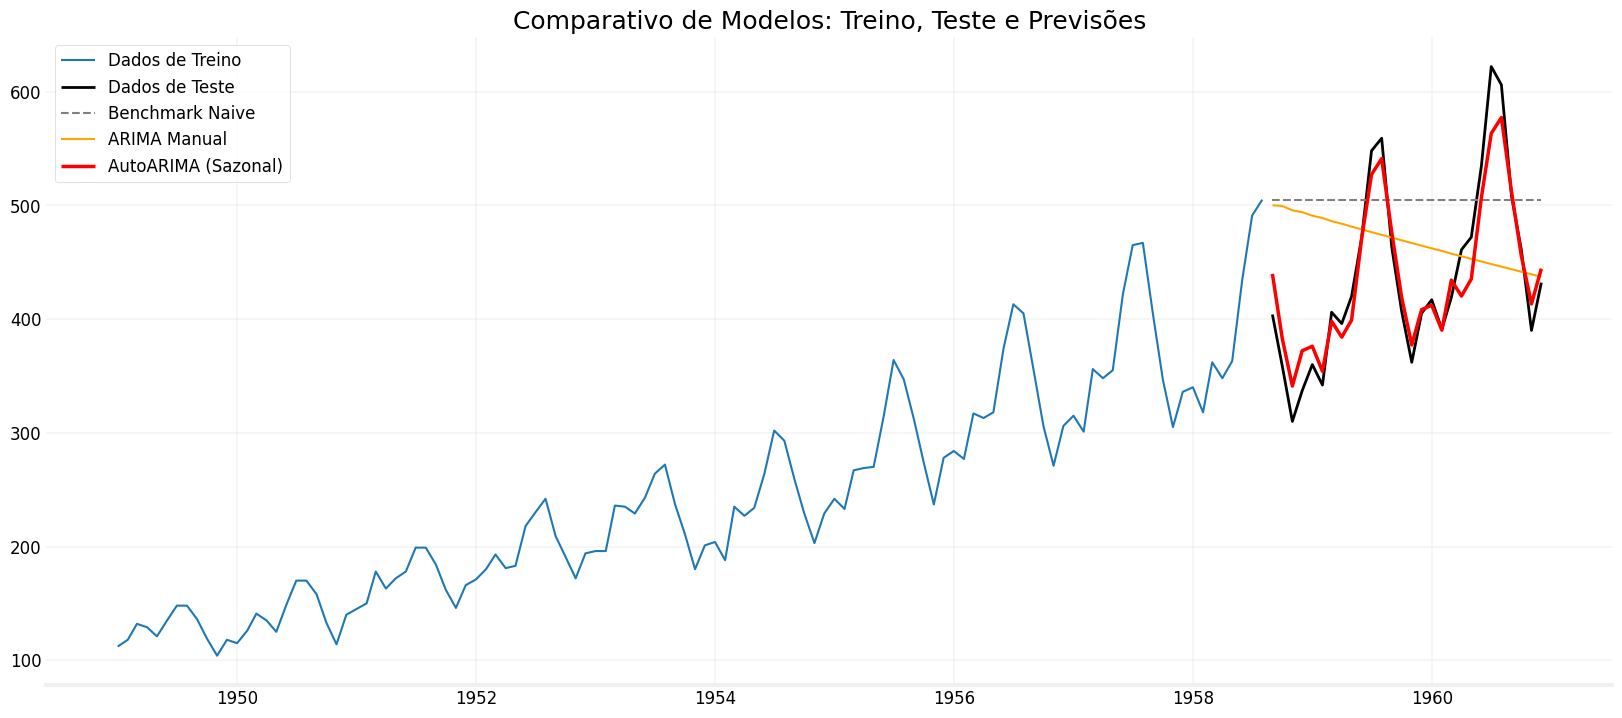

In [23]:
PrevisoesDF = pd.DataFrame(index=TesteDF.index)
PrevisoesDF['Real (Teste)'] = TesteDF['Teste'].values
PrevisoesDF['Naive'] = PrevisaoNaive
PrevisoesDF['ARIMA Manual'] = PrevisaoARIMA_Manual.values
PrevisoesDF['AutoARIMA'] = PrevisaoAutoARIMA

plt.figure(figsize=(18, 8))
plt.plot(TreinoDF.index, TreinoDF['Treino'], label='Dados de Treino', color='#1f77b4')
plt.plot(PrevisoesDF.index, PrevisoesDF['Real (Teste)'], label='Dados de Teste', color='black', linewidth=2)
plt.plot(PrevisoesDF.index, PrevisoesDF['Naive'], label='Benchmark Naive', linestyle='--', color='gray')
plt.plot(PrevisoesDF.index, PrevisoesDF['ARIMA Manual'], label='ARIMA Manual', color='orange')
plt.plot(PrevisoesDF.index, PrevisoesDF['AutoARIMA'], label='AutoARIMA (Sazonal)', color='red', linewidth=2.5)

plt.title('Comparativo de Modelos: Treino, Teste e Previsões', fontsize=18)
plt.legend()
plt.show()

In [24]:
# Cálculo do quadro final de métricas
met_arima = calcular_metricas(TesteDF['Teste'], PrevisaoARIMA_Manual, TreinoDF['Treino'])
met_auto = calcular_metricas(TesteDF['Teste'], PrevisaoAutoARIMA, TreinoDF['Treino'])

Comparativo = pd.DataFrame({
    'Baseline (Naive)': metricas_naive,
    'ARIMA Manual': met_arima,
    'AutoARIMA Sazonal': met_auto
})

print("=== CONSOLIDAÇÃO DE MÉTRICAS DE ERRO ===")
display(Comparativo.round(2))

print("\n*** Conclusões Didáticas ***")
print("- Note como o MASE cai vertiginosamente no modelo AutoARIMA, provando sua superioridade estatística em relação ao baseline.")
print("- O ARIMA Manual (sem o componente sazonal P,D,Q) captura a tendência através do 'd=1', mas falha em repetir o ciclo de subidas e descidas de meses de férias.")
print("- O AutoARIMA da Nixtla entende a Sazonalidade (m=12) de forma autônoma, reduzindo o MAPE para patamares muito menores.")

=== CONSOLIDAÇÃO DE MÉTRICAS DE ERRO ===


,Baseline (Naive),ARIMA Manual,AutoARIMA Sazonal
MAE,91.86,79.22,19.19
MSE,10656.71,9071.05,553.34
RMSE,103.23,95.24,23.52
MAPE (%),23.05,19.27,4.42
sMAPE (%),20.18,17.64,4.41
MASE,4.37,3.77,0.91



*** Conclusões Didáticas ***
- Note como o MASE cai vertiginosamente no modelo AutoARIMA, provando sua superioridade estatística em relação ao baseline.
- O ARIMA Manual (sem o componente sazonal P,D,Q) captura a tendência através do 'd=1', mas falha em repetir o ciclo de subidas e descidas de meses de férias.
- O AutoARIMA da Nixtla entende a Sazonalidade (m=12) de forma autônoma, reduzindo o MAPE para patamares muito menores.
